In [2]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DATA_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData"
OUTPUT_DIR = os.path.join(BASE_DATA_PATH, "processed")

os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style("whitegrid")

print(f"Base data path set to: {BASE_DATA_PATH}")
print(f"Processed output will be saved to: {OUTPUT_DIR}")

Base data path set to: C:\Users\Enjoy\OneDrive\Desktop\STData
Processed output will be saved to: C:\Users\Enjoy\OneDrive\Desktop\STData\processed


In [3]:

student_folders = sorted(
    [d for d in glob(os.path.join(BASE_DATA_PATH, "*")) if os.path.isdir(d) and os.path.basename(d).isdigit()],
    key=lambda path: int(os.path.basename(path))
)

if student_folders:
    inspect_path = student_folders[0]
    inspect_id = os.path.basename(inspect_path)
    print(f"Selected Student '{inspect_id}' for inspection.")
else:
    print("No student folders with numeric names were found in the base path.")
    inspect_path = None

Selected Student '1' for inspection.


In [4]:
if inspect_path:

    psy_file = glob(os.path.join(inspect_path, "*PSY.csv"))[0]
    eeg_file = glob(os.path.join(inspect_path, "*EEG.csv"))[0]
    eye_file = glob(os.path.join(inspect_path, "*EYE.csv"))[0]
    ivt_file = glob(os.path.join(inspect_path, "*IVT.csv"))[0]
    
    psy_df = pd.read_csv(psy_file)
    eeg_df = pd.read_csv(eeg_file)
    eye_df = pd.read_csv(eye_file)
    ivt_df = pd.read_csv(ivt_file)
    
    print("Successfully loaded PSY, EEG, EYE, and IVT dataframes for inspection.")

C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10492\4161674137.py:9: DtypeWarning: Columns (2,40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_df = pd.read_csv(eeg_file)


Successfully loaded PSY, EEG, EYE, and IVT dataframes for inspection.


In [5]:
print("--- PSY Data Info ---")
psy_df.info()

print("\n--- PSY Data Head ---")
display(psy_df.head())

--- PSY Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Key               40 non-null     object 
 1   Category          40 non-null     int64  
 2   QuestionNumber    40 non-null     object 
 3   matchOrnomatch    39 non-null     object 
 4   Difficulty        39 non-null     object 
 5   verdict           39 non-null     object 
 6   ResponseTime      40 non-null     float64
 7   routineStart      40 non-null     float64
 8   routineStamp      40 non-null     object 
 9   routineEnd        40 non-null     float64
 10  Cat2FeedbackTime  10 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 3.6+ KB

--- PSY Data Head ---


,Key,Category,QuestionNumber,matchOrnomatch,Difficulty,verdict,ResponseTime,routineStart,routineStamp,routineEnd,Cat2FeedbackTime
0,1spl1,1,spl1,match,Easy,CORRECT,10.369816,1.680003e+09,"28/03/2023, 17:04:09",1.680003e+09,NaN
1,1spl2,1,spl2,nomatch,Easy,CORRECT,7.913992,1.680003e+09,"28/03/2023, 17:04:20",1.680003e+09,NaN
2,1Item1,1,Item1,match,Easy,CORRECT,7.654472,1.680003e+09,"28/03/2023, 17:04:28",1.680003e+09,NaN
3,1Item2,1,Item2,match,Easy,CORRECT,14.597205,1.680003e+09,"28/03/2023, 17:04:35",1.680003e+09,NaN
4,1Item3,1,Item3,match,Easy,CORRECT,16.476566,1.680003e+09,"28/03/2023, 17:04:50",1.680003e+09,NaN


In [6]:
print("--- EEG Data Info ---")
eeg_df.info()

print("\n--- EEG Data Head ---")
display(eeg_df.head())

--- EEG Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203240 entries, 0 to 203239
Data columns (total 41 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TimeStamp        203240 non-null  object 
 1   UnixTime         203240 non-null  float64
 2   QuestionKey      130326 non-null  object 
 3   Delta_TP9        203228 non-null  float64
 4   Delta_AF7        203228 non-null  float64
 5   Delta_AF8        203228 non-null  float64
 6   Delta_TP10       203228 non-null  float64
 7   Theta_TP9        203228 non-null  float64
 8   Theta_AF7        203228 non-null  float64
 9   Theta_AF8        203228 non-null  float64
 10  Theta_TP10       203228 non-null  float64
 11  Alpha_TP9        203228 non-null  float64
 12  Alpha_AF7        203228 non-null  float64
 13  Alpha_AF8        203228 non-null  float64
 14  Alpha_TP10       203228 non-null  float64
 15  Beta_TP9         203228 non-null  float64
 16  Beta_AF7        

,TimeStamp,UnixTime,QuestionKey,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,...,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery,Elements
0,2023-03-28 17:03:16.773,1.680003e+09,NaN,0.558597,-0.100425,0.475775,1.85526,0.509486,-0.135816,-0.222424,...,-0.710297,2.579498,4.42627,1.0,1.0,1.0,1.0,2.0,92.98,NaN
1,2023-03-28 17:03:16.776,1.680003e+09,NaN,0.558597,-0.100425,0.475775,1.85526,0.509486,-0.135816,-0.222424,...,-0.710297,2.579498,4.42627,1.0,1.0,1.0,1.0,2.0,92.98,NaN
2,2023-03-28 17:03:16.778,1.680003e+09,NaN,0.558597,-0.100425,0.475775,1.85526,0.509486,-0.135816,-0.222424,...,-0.710297,2.579498,4.42627,1.0,1.0,1.0,1.0,2.0,92.98,NaN
3,2023-03-28 17:03:16.798,1.680003e+09,NaN,0.558597,-0.100425,0.475775,1.85526,0.509486,-0.135816,-0.222424,...,-0.710297,2.579498,4.42627,1.0,1.0,1.0,1.0,2.0,92.98,NaN
4,2023-03-28 17:03:16.801,1.680003e+09,NaN,0.558597,-0.100425,0.475775,1.85526,0.509486,-0.135816,-0.222424,...,-0.710297,2.579498,4.42627,1.0,1.0,1.0,1.0,2.0,92.98,NaN


In [7]:
print("--- EYE Data Info ---")
eye_df.info()

print("\n--- EYE Data Head ---")
display(eye_df.head())

print("\n--- IVT (Fixation/Saccade) Data Info ---")
ivt_df.info()

print("\n--- IVT Data Head ---")
display(ivt_df.head())

--- EYE Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89327 entries, 0 to 89326
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UnixTime          89327 non-null  float64
 1   Row               89327 non-null  int64  
 2   QuestionKey       51218 non-null  object 
 3   Timestamp         89327 non-null  object 
 4   ET_GazeLeftx      89323 non-null  float64
 5   ET_GazeLefty      89323 non-null  float64
 6   ET_GazeRightx     89323 non-null  float64
 7   ET_GazeRighty     89323 non-null  float64
 8   ET_PupilLeft      89323 non-null  float64
 9   ET_PupilRight     89323 non-null  float64
 10  ET_TimeSignal     89323 non-null  float64
 11  ET_DistanceLeft   89323 non-null  float64
 12  ET_DistanceRight  89323 non-null  float64
 13  ET_CameraLeftX    89323 non-null  float64
 14  ET_CameraLeftY    89323 non-null  float64
 15  ET_CameraRightX   89323 non-null  float64
 16  ET_CameraRightY   

,UnixTime,Row,QuestionKey,Timestamp,ET_GazeLeftx,ET_GazeLefty,ET_GazeRightx,ET_GazeRighty,ET_PupilLeft,ET_PupilRight,ET_TimeSignal,ET_DistanceLeft,ET_DistanceRight,ET_CameraLeftX,ET_CameraLeftY,ET_CameraRightX,ET_CameraRightY,ET_ValidityLeft,ET_ValidityRight
0,1.680003e+09,1,NaN,2023-03-28 17:02:25.028903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.680003e+09,2,NaN,2023-03-28 17:02:25.033038,989.0,624.0,979.0,577.0,-1.0,-1.000000,41.388,595.763672,590.328552,0.583813,0.497461,0.427234,0.497041,0.0,0.0
2,1.680003e+09,3,NaN,2023-03-28 17:02:25.041360,-1.0,-1.0,978.0,577.0,-1.0,2.594193,49.709,-1.000000,590.240540,-1.000000,-1.000000,0.427174,0.497101,4.0,0.0
3,1.680003e+09,4,NaN,2023-03-28 17:02:25.049869,960.0,579.0,981.0,575.0,-1.0,-1.000000,58.219,595.961853,590.165833,0.583723,0.497516,0.427158,0.497103,0.0,0.0
4,1.680003e+09,5,NaN,2023-03-28 17:02:25.058035,965.0,571.0,980.0,590.0,-1.0,-1.000000,66.382,595.985657,590.191040,0.583844,0.497511,0.427234,0.497044,0.0,0.0



--- IVT (Fixation/Saccade) Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89327 entries, 0 to 89326
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   UnixTime                    89327 non-null  float64
 1   Row                         89327 non-null  int64  
 2   QuestionKey                 51218 non-null  object 
 3   Timestamp                   89327 non-null  object 
 4   Gaze X                      83098 non-null  float64
 5   Gaze Y                      83004 non-null  float64
 6   Interpolated Gaze X         83098 non-null  float64
 7   Interpolated Gaze Y         83004 non-null  float64
 8   Interpolated Distance       83123 non-null  float64
 9   Gaze Velocity               79766 non-null  float64
 10  Gaze Acceleration           78535 non-null  float64
 11  Fixation Index              70731 non-null  float64
 12  Fixation Index by Stimulus  70541 non-null  fl

,UnixTime,Row,QuestionKey,Timestamp,Gaze X,Gaze Y,Interpolated Gaze X,Interpolated Gaze Y,Interpolated Distance,Gaze Velocity,...,Saccade Index,Saccade Index by Stimulus,Saccade Start,Saccade End,Saccade Duration,Saccade Amplitude,Saccade Peak Velocity,Saccade Peak Acceleration,Saccade Peak Deceleration,Saccade Direction
0,1.680003e+09,1,NaN,2023-03-28 17:02:25.028903,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.680003e+09,2,NaN,2023-03-28 17:02:25.033038,984.0,600.5,980.666667,583.833333,593.046112,16.436836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.680003e+09,3,NaN,2023-03-28 17:02:25.041360,978.0,577.0,977.500000,584.833333,590.240540,9.282013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.680003e+09,4,NaN,2023-03-28 17:02:25.049869,970.5,577.0,973.666667,578.166667,593.063843,18.472074,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.680003e+09,5,NaN,2023-03-28 17:02:25.058035,972.5,580.5,964.000000,596.500000,593.088348,22.690880,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


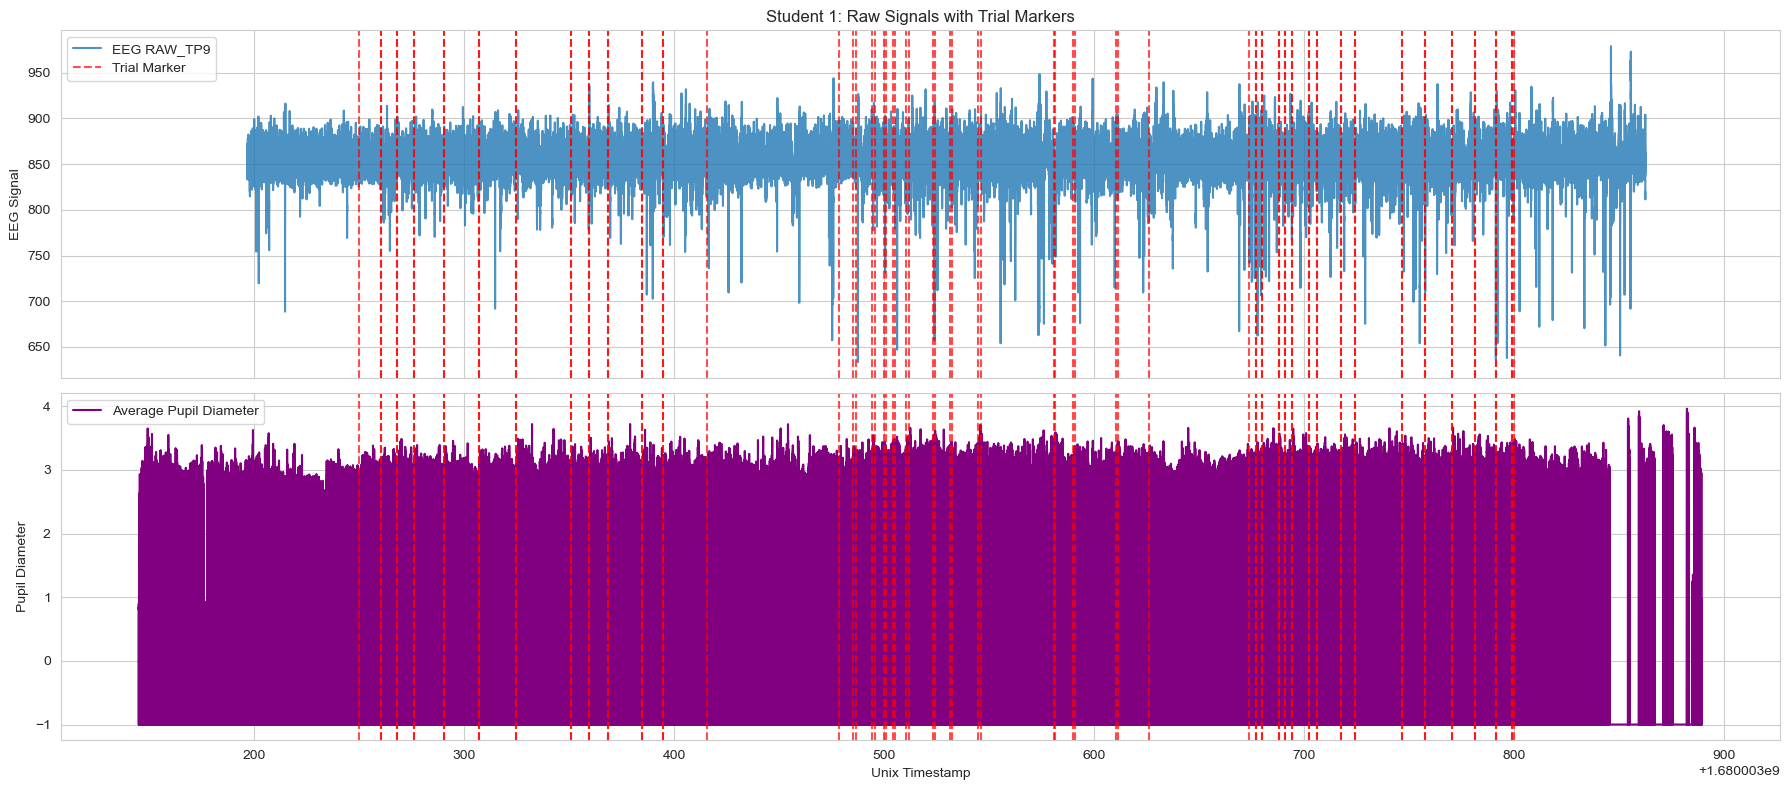

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

ax1.plot(eeg_df['UnixTime'], eeg_df['RAW_TP9'], label='EEG RAW_TP9', alpha=0.8)
ax1.set_title(f'Student {inspect_id}: Raw Signals with Trial Markers')
ax1.set_ylabel('EEG Signal')
ax1.legend()


avg_pupil = eye_df[['ET_PupilLeft', 'ET_PupilRight']].mean(axis=1)
ax2.plot(eye_df['UnixTime'], avg_pupil, label='Average Pupil Diameter', color='purple')
ax2.set_ylabel('Pupil Diameter')
ax2.set_xlabel('Unix Timestamp')
ax2.legend()

for idx, row in psy_df.iterrows():
    ax1.axvline(x=row['routineStart'], color='r', linestyle='--', alpha=0.7, label='Trial Marker' if idx == 0 else "")
    ax1.axvline(x=row['routineEnd'], color='r', linestyle='--', alpha=0.7)
    ax2.axvline(x=row['routineStart'], color='r', linestyle='--', alpha=0.7)
    ax2.axvline(x=row['routineEnd'], color='r', linestyle='--', alpha=0.7)

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

In [9]:
def process_student_folder(folder_path, student_id):
    """
    Loads data, synchronizes timestamps, slices by trial, and saves the output.
    """
    print(f"--- Processing student folder: {os.path.basename(folder_path)} ---")
    
    psy_file, eeg_file, eye_file, ivt_file = (glob(os.path.join(folder_path, f"*_{ftype}.csv")) for ftype in ["PSY", "EEG", "EYE", "IVT"])

    if not (psy_file and eeg_file and eye_file and ivt_file):
        print(f"  -> Skipping {os.path.basename(folder_path)} due to missing files.")
        return

    try:
        psy_df = pd.read_csv(psy_file[0])
        eeg_df = pd.read_csv(eeg_file[0], low_memory=False)
        eye_df = pd.read_csv(eye_file[0], low_memory=False)
        ivt_df = pd.read_csv(ivt_file[0], low_memory=False)
    except Exception as e:
        print(f"  -> ERROR reading files for student {student_id}: {e}")
        return

    for df in [eeg_df, eye_df, ivt_df]:
        if "UnixTime" in df.columns:
            df["UnixTime"] = pd.to_numeric(df["UnixTime"], errors='coerce')
            df.dropna(subset=["UnixTime"], inplace=True)

    for col in ["routineStart", "routineEnd", "ResponseTime"]:
        psy_df[col] = pd.to_numeric(psy_df[col], errors='coerce')
    psy_df.dropna(subset=["routineStart", "routineEnd", "ResponseTime"], inplace=True)

    for idx, row in psy_df.iterrows():
        start_time, end_time, response_time = row["routineStart"], row["routineEnd"], row["ResponseTime"]
        trial_id = f"student_{student_id}_trial_{idx}"
        
        eeg_trial = eeg_df[(eeg_df["UnixTime"] >= start_time) & (eeg_df["UnixTime"] <= end_time)]
        eye_trial = eye_df[(eye_df["UnixTime"] >= start_time) & (eye_df["UnixTime"] <= end_time)]
        ivt_trial = ivt_df[(ivt_df["UnixTime"] >= start_time) & (ivt_df["UnixTime"] <= end_time)]

        if eeg_trial.empty or eye_trial.empty or ivt_trial.empty:
            print(f"  -> Skipping trial {idx} for student {student_id} due to empty data slices.")
            continue

        student_output_dir = os.path.join(OUTPUT_DIR, str(student_id))
        os.makedirs(student_output_dir, exist_ok=True)
        
        eeg_trial.to_csv(os.path.join(student_output_dir, f"{trial_id}_eeg.csv"), index=False)
        eye_trial.to_csv(os.path.join(student_output_dir, f"{trial_id}_eye.csv"), index=False)
        ivt_trial.to_csv(os.path.join(student_output_dir, f"{trial_id}_ivt.csv"), index=False)
        pd.DataFrame([{"ResponseTime": response_time}]).to_csv(os.path.join(student_output_dir, f"{trial_id}_meta.csv"), index=False)
    
    print(f"--- Finished processing student {student_id} ---")

In [10]:
print("--- Starting Main Preprocessing Pipeline ---")

if not student_folders:
    print("\n No student folders with numeric names found in the base path.")
else:
    for folder in student_folders:
        student_id = os.path.basename(folder)
        process_student_folder(folder, student_id=student_id)
    
    print(f"\n Preprocessing complete. Sliced data saved to the '{OUTPUT_DIR}' directory.")

--- Starting Main Preprocessing Pipeline ---
--- Processing student folder: 1 ---
--- Finished processing student 1 ---
--- Processing student folder: 2 ---
--- Finished processing student 2 ---
--- Processing student folder: 3 ---
--- Finished processing student 3 ---
--- Processing student folder: 4 ---
--- Finished processing student 4 ---
--- Processing student folder: 5 ---
--- Finished processing student 5 ---
--- Processing student folder: 6 ---
--- Finished processing student 6 ---
--- Processing student folder: 7 ---
--- Finished processing student 7 ---
--- Processing student folder: 8 ---
--- Finished processing student 8 ---
--- Processing student folder: 9 ---
--- Finished processing student 9 ---
--- Processing student folder: 10 ---
  -> Skipping trial 0 for student 10 due to empty data slices.
  -> Skipping trial 1 for student 10 due to empty data slices.
  -> Skipping trial 2 for student 10 due to empty data slices.
  -> Skipping trial 3 for student 10 due to empty dat

--- Finished processing student 38 ---

 Preprocessing complete. Sliced data saved to the 'C:\Users\Enjoy\OneDrive\Desktop\STData\processed' directory.


In [11]:
if os.path.exists(OUTPUT_DIR):
    processed_student_dirs = [d for d in os.listdir(OUTPUT_DIR) if os.path.isdir(os.path.join(OUTPUT_DIR, d))]
    total_trials = sum(len(glob(os.path.join(OUTPUT_DIR, s_dir, "*_meta.csv"))) for s_dir in processed_student_dirs)

    print("\n--- Preprocessing Summary ---")
    print(f"Total number of student folders created: {len(processed_student_dirs)}")
    print(f"Total number of trials saved: {total_trials}")

    # Inspect the head of one of the processed files
    if total_trials > 0:
        first_trial_file = glob(os.path.join(OUTPUT_DIR, "*", "*_eeg.csv"))[0]
        print(f"\n--- Inspecting a sample processed file: {os.path.basename(first_trial_file)} ---")
        processed_sample_df = pd.read_csv(first_trial_file)
        display(processed_sample_df.head())
else:
    print("\nOutput directory not found. Did the processing step run correctly?")


--- Preprocessing Summary ---
Total number of student folders created: 75
Total number of trials saved: 2891

--- Inspecting a sample processed file: student_1_trial_0_eeg.csv ---


,TimeStamp,UnixTime,QuestionKey,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,...,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery,Elements
0,2023-03-28 17:04:09.790,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN
1,2023-03-28 17:04:09.792,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN
2,2023-03-28 17:04:09.794,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN
3,2023-03-28 17:04:09.796,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN
4,2023-03-28 17:04:09.825,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.560760,2.392578,4.119720,1.0,1.0,1.0,1.0,1.0,92.89,NaN
